In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Define paths
admissions_path = "../data/Mimic-3_patients/ADMISSIONS/ADMISSIONS_sorted.csv"
notes_path = "../data/Mimic-3_patients/NOTEEVENTS/NOTEEVENTS_sorted.csv"
figure_dir = "../notebooks/figures/"
os.makedirs(figure_dir, exist_ok=True)


In [3]:
# Load data
df_adm = pd.read_csv(admissions_path)
df_notes = pd.read_csv(notes_path)

In [4]:
# Merge admissions with discharge summaries
df_merged = df_notes[df_notes["CATEGORY"] == "Discharge summary"].merge(
    df_adm[["HADM_ID", "ADMITTIME", "DISCHTIME", "DEATHTIME"]],
    on="HADM_ID", how="left"
)

In [5]:
# Convert date columns to datetime
df_merged["ADMITTIME"] = pd.to_datetime(df_merged["ADMITTIME"])
df_merged["DISCHTIME"] = pd.to_datetime(df_merged["DISCHTIME"])
df_merged["DEATHTIME"] = pd.to_datetime(df_merged["DEATHTIME"])


In [6]:
# Calculate hospital length of stay and time to death
df_merged["LOS_days"] = (df_merged["DISCHTIME"] - df_merged["ADMITTIME"]).dt.total_seconds() / (60 * 60 * 24)
df_merged["Time_to_death_days"] = (df_merged["DEATHTIME"] - df_merged["DISCHTIME"]).dt.total_seconds() / (60 * 60 * 24)


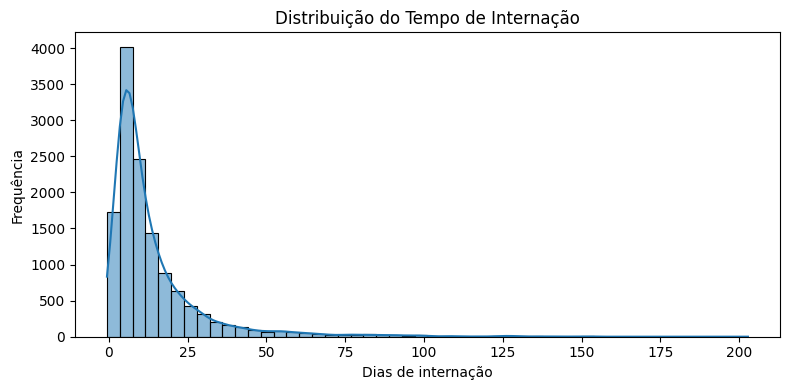

In [16]:
# Plot length of stay distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_merged["LOS_days"].dropna(), bins=50, kde=True)
plt.title("Distribuição do Tempo de Internação")
plt.xlabel("Dias de internação")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "distribuicao_tempo_internacao.png"))
plt.show()
plt.close()

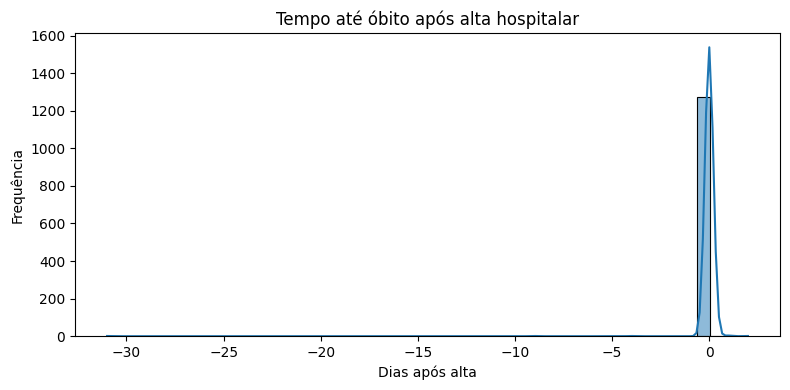

In [15]:

# Plot time to death after discharge
plt.figure(figsize=(8, 4))
sns.histplot(df_merged["Time_to_death_days"].dropna(), bins=50, kde=True)
plt.title("Tempo até óbito após alta hospitalar")
plt.xlabel("Dias após alta")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, "tempo_ate_obito_pos_alta.png"))
plt.show()
plt.close()

In [10]:
# Visualização simples em ambiente local
df_merged[["HADM_ID", "ADMITTIME", "DISCHTIME", "DEATHTIME", "LOS_days", "Time_to_death_days"]].head(10)


,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,LOS_days,Time_to_death_days
0,145834.0,2101-10-20 19:08:00,2101-10-31 13:58:00,NaT,10.784722,NaN
1,185777.0,2191-03-16 00:28:00,2191-03-23 18:41:00,NaT,7.759028,NaN
2,107064.0,2175-05-30 07:15:00,2175-06-15 16:00:00,NaT,16.364583,NaN
3,150750.0,2149-11-09 13:06:00,2149-11-14 10:15:00,2149-11-14 10:15:00,4.881250,0.0
4,150750.0,2149-11-09 13:06:00,2149-11-14 10:15:00,2149-11-14 10:15:00,4.881250,0.0
5,184167.0,2103-06-28 11:36:00,2103-07-06 12:10:00,NaT,8.023611,NaN
6,194540.0,2178-04-16 06:18:00,2178-05-11 19:00:00,NaT,25.529167,NaN
7,112213.0,2104-08-07 10:15:00,2104-08-20 02:57:00,2104-08-20 02:57:00,12.695833,0.0
8,143045.0,2167-01-08 18:43:00,2167-01-15 15:15:00,NaT,6.855556,NaN
9,143045.0,2167-01-08 18:43:00,2167-01-15 15:15:00,NaT,6.855556,NaN


In [13]:
display(df_merged[["HADM_ID", "ADMITTIME", "DISCHTIME", "DEATHTIME", "LOS_days", "Time_to_death_days"]].head(10))


,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,LOS_days,Time_to_death_days
0,145834.0,2101-10-20 19:08:00,2101-10-31 13:58:00,NaT,10.784722,NaN
1,185777.0,2191-03-16 00:28:00,2191-03-23 18:41:00,NaT,7.759028,NaN
2,107064.0,2175-05-30 07:15:00,2175-06-15 16:00:00,NaT,16.364583,NaN
3,150750.0,2149-11-09 13:06:00,2149-11-14 10:15:00,2149-11-14 10:15:00,4.881250,0.0
4,150750.0,2149-11-09 13:06:00,2149-11-14 10:15:00,2149-11-14 10:15:00,4.881250,0.0
5,184167.0,2103-06-28 11:36:00,2103-07-06 12:10:00,NaT,8.023611,NaN
6,194540.0,2178-04-16 06:18:00,2178-05-11 19:00:00,NaT,25.529167,NaN
7,112213.0,2104-08-07 10:15:00,2104-08-20 02:57:00,2104-08-20 02:57:00,12.695833,0.0
8,143045.0,2167-01-08 18:43:00,2167-01-15 15:15:00,NaT,6.855556,NaN
9,143045.0,2167-01-08 18:43:00,2167-01-15 15:15:00,NaT,6.855556,NaN


In [14]:

# 2. Salva o dataframe completo com variáveis temporais
output_path = "../processed/temporal_mortality_features.csv"
df_merged.to_csv(output_path, index=False)
print(f"Dados processados com colunas temporais salvos em: {output_path}")

✅ Dados processados com colunas temporais salvos em: ../processed/temporal_mortality_features.csv
